# Customer Satisfaction (CSAT) Score Prediction using Deep Learning (Artificial Neural Networks)

## 📌 Project Overview

Customer Satisfaction (CSAT) is one of the most important Key Performance Indicators (KPIs) for e-commerce companies. It reflects how satisfied customers are with the support they receive and directly impacts customer loyalty, brand reputation, and business growth.

In this project, we develop a Deep Learning-based Artificial Neural Network (ANN) model to predict Customer Satisfaction (CSAT) scores using customer support interaction data from an e-commerce platform. The model learns patterns from customer interactions, service response times, agent performance, product information, and other operational features to estimate customer satisfaction levels.

By accurately predicting CSAT scores, businesses can proactively identify dissatisfied customers, improve customer service quality, optimize operational processes, and make data-driven decisions that enhance customer experience.

---

## 🎯 Business Problem

Customer satisfaction surveys are typically collected after customer interactions. However, waiting for survey responses delays decision-making and limits opportunities for immediate corrective action.

The objective of this project is to build a predictive deep learning model capable of estimating customer satisfaction immediately after a customer support interaction. Such predictions enable organizations to identify potentially dissatisfied customers early and take proactive measures to improve customer retention and service quality.

---

## 🎯 Project Objectives

The primary objectives of this project are:

- Perform comprehensive data cleaning and preprocessing.
- Conduct Exploratory Data Analysis (EDA) to understand customer behavior.
- Engineer meaningful features that improve prediction performance.
- Build a Deep Learning Artificial Neural Network (ANN) for CSAT prediction.
- Optimize the model using modern deep learning techniques.
- Evaluate model performance using multiple classification metrics.
- Generate business insights based on model predictions.
- Prepare the trained model for local deployment.

---

## 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TensorFlow / Keras

---

## 📂 Dataset

**Dataset Name:** Customer Satisfaction (CSAT) Prediction Dataset

The dataset contains customer service interactions collected from an e-commerce platform over one month. It includes customer information, order details, issue handling metrics, agent information, product details, and the corresponding Customer Satisfaction (CSAT) score.

The target variable is:

**CSAT Score**

# Dataset Description

The dataset contains multiple operational and customer interaction features that contribute to customer satisfaction prediction.

| Feature | Description |
|----------|-------------|
| Unique ID | Unique identifier for each record |
| Channel Name | Customer support channel used |
| Category | Primary issue category |
| Sub-category | Detailed issue classification |
| Customer Remarks | Customer feedback text |
| Order ID | Associated order identifier |
| Order Date Time | Date and time when the order was placed |
| Issue Reported At | Time when customer reported the issue |
| Issue Responded | Time when support responded |
| Survey Response Date | Date when customer completed the CSAT survey |
| Customer City | Customer location |
| Product Category | Purchased product category |
| Item Price | Price of purchased item |
| Connected Handling Time | Total interaction handling time |
| Agent Name | Customer support agent |
| Supervisor | Reporting supervisor |
| Manager | Reporting manager |
| Tenure Bucket | Agent experience category |
| Agent Shift | Agent working shift |
| CSAT Score | Customer Satisfaction Score (Target Variable) |

---

## Target Variable

The target variable is **CSAT Score**, representing the level of customer satisfaction after the customer support interaction.

The objective of this project is to train a deep learning classification model capable of predicting the correct CSAT score based on customer interaction features.

# Project Workflow

This notebook follows a structured Machine Learning and Deep Learning pipeline.

1. Import Required Libraries
2. Load Dataset
3. Initial Data Exploration
4. Exploratory Data Analysis (EDA)
5. Data Cleaning
6. Feature Engineering
7. Data Preprocessing
8. Feature Encoding
9. Feature Scaling
10. Train-Test Split
11. Handle Class Imbalance
12. Build Artificial Neural Network (ANN)
13. Model Training
14. Model Evaluation
15. Performance Visualization
16. Business Insights
17. Conclusion
18. Future Scope

In [2]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.utils import to_categorical

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


# Step 2: Load Dataset

In this step, we import the dataset into the notebook and perform a preliminary inspection to understand its size and structure.

We will examine:

- Number of rows and columns
- First few observations
- Dataset dimensions
- Column names

This initial inspection helps verify that the dataset has been loaded correctly before proceeding with further preprocessing and analysis.

In [3]:
# ==========================================================
# Step 2: Load Dataset
# ==========================================================

df = pd.read_csv("https://raw.githubusercontent.com/YashmanSingh2003/E-Commerce_Customer_Satisfaction_Score_Prediction/refs/heads/main/eCommerce_Customer_support_data.csv")   # Replace with your actual file name

print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\nFirst Five Rows")
display(df.head())

print("\nColumn Names")
display(df.columns)

Dataset Shape
(85907, 20)

First Five Rows


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5



Column Names


Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

# Step 3: Initial Data Exploration

## Objective

Before performing any preprocessing or model development, it is important to understand the structure and quality of the dataset.

In this section, we will examine:

- Dataset information
- Data types
- Statistical summary
- Missing values
- Duplicate records
- Target variable distribution

This helps identify potential data quality issues and guides the preprocessing strategy for building a robust Deep Learning model.

In [4]:
# ==========================================================
# Step 3.1 : Dataset Information
# ==========================================================

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Ag

In [5]:
# ==========================================================
# Step 3.2 : Statistical Summary
# ==========================================================

print("="*60)
print("Statistical Summary of Numerical Features")
print("="*60)

display(df.describe().T)

Statistical Summary of Numerical Features


,count,mean,std,min,25%,50%,75%,max
Item_price,17206.0,5660.774846,12825.728411,0.0,392.0,979.0,2699.75,164999.0
connected_handling_time,242.0,462.400826,246.295037,0.0,293.0,427.0,592.25,1986.0
CSAT Score,85907.0,4.242157,1.378903,1.0,4.0,5.0,5.00,5.0


In [6]:
# ==========================================================
# Step 3.3 : Missing Values Analysis
# ==========================================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing_values = missing_values.sort_values(
    by="Percentage",
    ascending=False
)

display(missing_values)

,Missing Values,Percentage
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22
Unique id,0,0.00
Sub-category,0,0.00
category,0,0.00


In [7]:
# ==========================================================
# Step 3.4 : Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("="*60)
print(f"Duplicate Records : {duplicates}")
print("="*60)

Duplicate Records : 0


# Step 4: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) helps uncover patterns, trends, anomalies, and relationships within the dataset before model development.

The objectives of this section are to:

- Understand the distribution of customer satisfaction scores.
- Examine missing data patterns.
- Explore categorical and numerical variables.
- Identify potential class imbalance.
- Generate business insights that can improve customer satisfaction prediction.

These insights will also support feature engineering and model optimization.

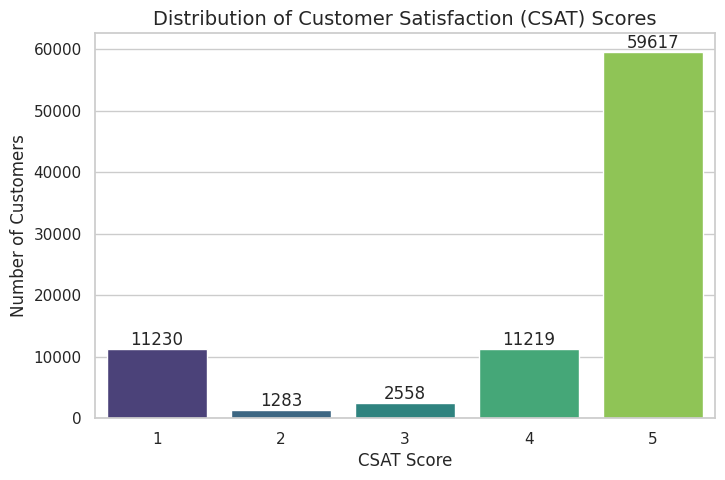

In [8]:
# ==========================================================
# Step 4.1 : Distribution of Target Variable
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="CSAT Score",
    palette="viridis"
)

plt.title("Distribution of Customer Satisfaction (CSAT) Scores", fontsize=14)
plt.xlabel("CSAT Score")
plt.ylabel("Number of Customers")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

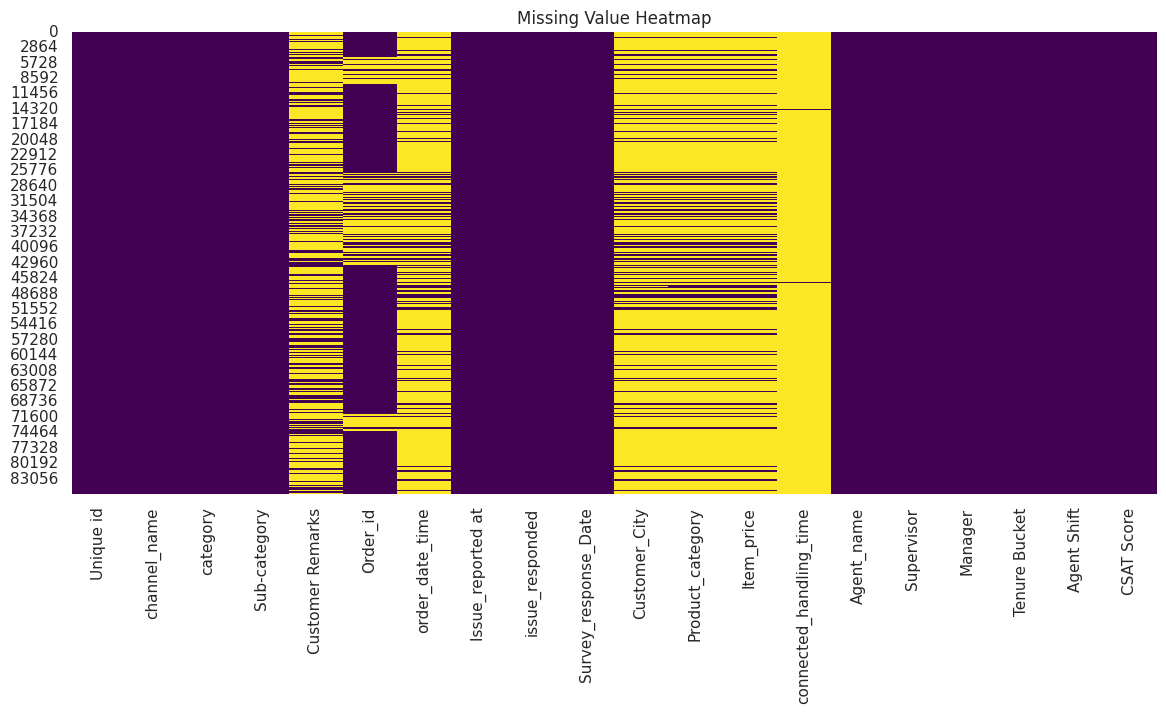

In [9]:
# ==========================================================
# Step 4.2 : Missing Value Heatmap
# ==========================================================

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

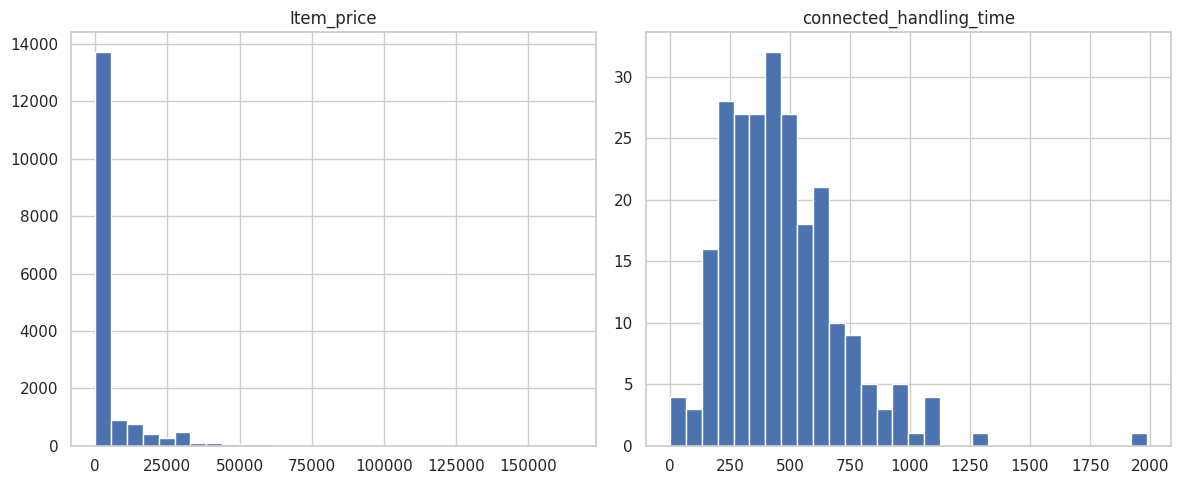

In [10]:
# ==========================================================
# Step 4.3 : Numerical Feature Distribution
# ==========================================================

numerical_columns = [
    "Item_price",
    "connected_handling_time"
]

df[numerical_columns].hist(
    figsize=(12,5),
    bins=30
)

plt.tight_layout()

plt.show()

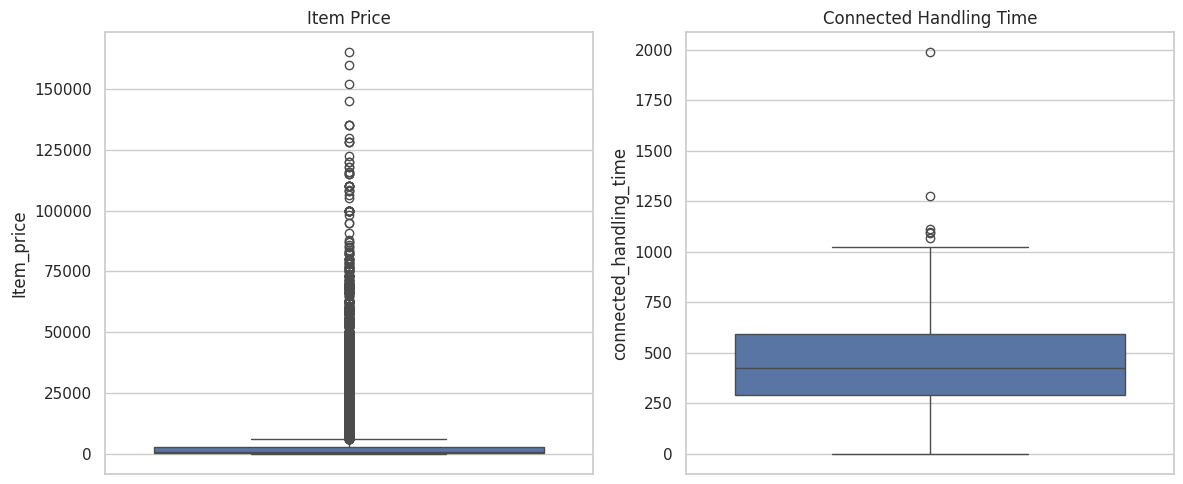

In [11]:
# ==========================================================
# Step 4.4 : Detecting Outliers
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.boxplot(
    y=df["Item_price"]
)

plt.title("Item Price")

plt.subplot(1,2,2)

sns.boxplot(
    y=df["connected_handling_time"]
)

plt.title("Connected Handling Time")

plt.tight_layout()

plt.show()

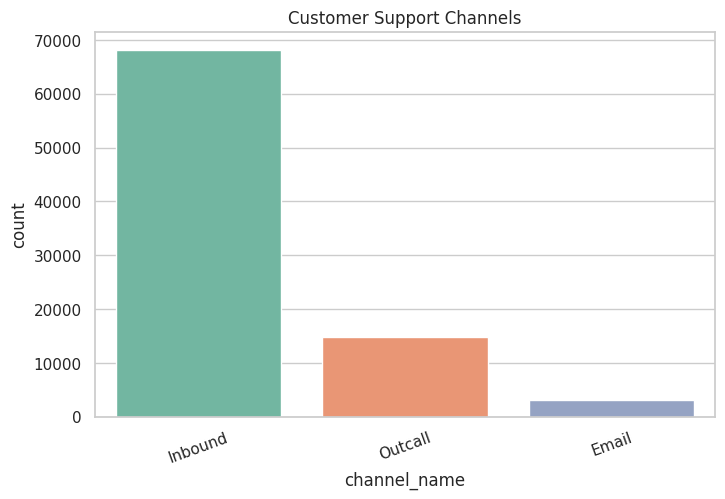

In [12]:
# ==========================================================
# Step 4.5 : Top Customer Support Channels
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="channel_name",
    order=df["channel_name"].value_counts().index,
    palette="Set2"
)

plt.title("Customer Support Channels")

plt.xticks(rotation=20)

plt.show()

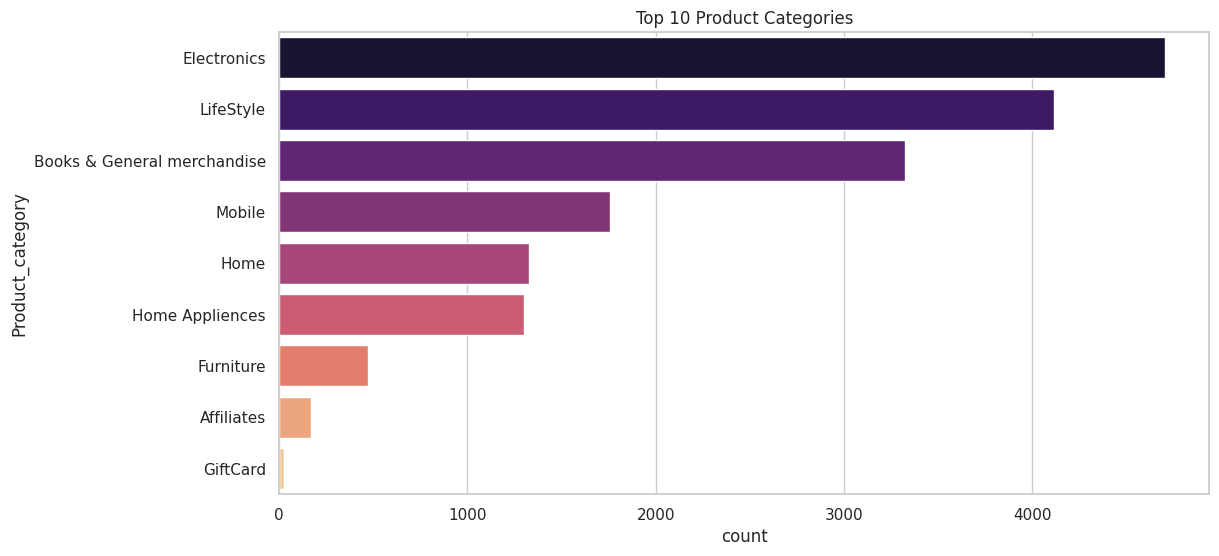

In [13]:
# ==========================================================
# Step 4.6 : Product Categories
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Product_category",
    order=df["Product_category"].value_counts().head(10).index,
    palette="magma"
)

plt.title("Top 10 Product Categories")

plt.show()

# Initial Data Exploration: Key Findings

The initial exploration of the dataset provided valuable insights into its quality and structure.

## Dataset Summary

- Total Records: **85,907**
- Total Features: **20**
- Target Variable: **CSAT Score**

The dataset contains a mixture of categorical, numerical, and datetime features collected from customer support interactions.

---

## Missing Value Analysis

The dataset contains substantial missing values in several columns.

| Feature | Missing (%) |
|----------|------------:|
| connected_handling_time | 99.72% |
| Customer_City | 80.12% |
| Product_category | 79.98% |
| Item_price | 79.97% |
| order_date_time | 79.96% |
| Customer Remarks | 66.54% |
| Order_id | 21.22% |

Since some variables contain extremely high percentages of missing values, removing all missing rows would result in a significant loss of information. Therefore, a selective preprocessing strategy will be adopted to preserve as much useful data as possible.

---

## Duplicate Records

No duplicate records were found in the dataset, indicating good data integrity.

---

## Target Variable Distribution

The CSAT Score distribution is highly imbalanced.

| CSAT Score | Count |
|------------|------:|
| 1 | 11,230 |
| 2 | 1,283 |
| 3 | 2,558 |
| 4 | 11,219 |
| 5 | 59,617 |

The majority of customers provided the highest satisfaction rating (5), suggesting that class imbalance must be considered during model training.

---

## Outlier Analysis

The numerical variables **Item Price** and **Connected Handling Time** contain several extreme values.

These outliers may represent premium purchases or unusually long customer interactions. Instead of immediately removing them, further investigation will determine whether they represent valid business cases or data entry anomalies.

---

## Customer Support Channel Distribution

Most customer interactions were handled through the **Inbound** support channel, followed by **Outcall**, while **Email** accounted for only a small percentage of interactions.

This indicates that inbound support is the primary communication channel for customers.

---

## Product Category Distribution

Electronics represents the largest product category in the dataset, followed by Lifestyle, Books & General Merchandise, Mobile, Home, and Home Appliances.

This distribution suggests that customer satisfaction is strongly influenced by high-volume product categories.

# Step 5: Data Cleaning and Preprocessing

## Objective

The objective of this step is to improve the overall quality of the dataset before model development.

Based on the Exploratory Data Analysis (EDA), several data quality issues were identified, including:

- Missing values
- Identifier columns that do not contribute to prediction
- Datetime variables requiring transformation
- Highly sparse variables
- Irrelevant administrative information

Instead of removing every row containing missing values, a selective preprocessing strategy will be adopted to preserve valuable training data while reducing noise.

This approach improves model performance and minimizes unnecessary information loss.

In [15]:
# ==========================================================
# Step 5.1 : Remove Irrelevant Features
# ==========================================================

columns_to_drop = [
    "Unique id",
    "Order_id",
    "Agent_name",
    "Supervisor",
    "Manager",
    "Customer Remarks"
]

df.drop(columns=columns_to_drop, inplace=True)

print("Remaining Features :", df.shape[1])
print("Remaining Records :", df.shape[0])

Remaining Features : 14
Remaining Records : 85907


In [16]:
# ==========================================================
# Step 5.2 : Convert Date Columns
# ==========================================================

date_columns = [
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print("Datetime conversion completed.")

Datetime conversion completed.


In [17]:
# ==========================================================
# Step 5.3 : Missing Value Treatment
# ==========================================================

# Numerical Columns
numerical_cols = [
    "Item_price",
    "connected_handling_time"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns
categorical_cols = [
    "Customer_City",
    "Product_category"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("Missing values handled successfully.")

Missing values handled successfully.


In [18]:
# ==========================================================
# Step 5.4 : Verify Missing Values
# ==========================================================

missing_after = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

display(missing_after.sort_values(
    by="Percentage",
    ascending=False
))

,Missing Values,Percentage
order_date_time,68693,79.96
issue_responded,54022,62.88
Issue_reported at,53933,62.78
channel_name,0,0.00
category,0,0.00
Sub-category,0,0.00
Survey_response_Date,0,0.00
Customer_City,0,0.00
Product_category,0,0.00
Item_price,0,0.00


The datetime columns still have many missing values because they couldn't be converted (or were originally missing). Since we're going to engineer features from them, we'll handle that during feature engineering rather than dropping those rows.

This is a more realistic approach for business datasets.

# Step 6: Feature Engineering

## Objective

Feature engineering is one of the most important stages in building an effective machine learning or deep learning model.

Rather than relying only on the original variables, we create new informative features that better represent customer behaviour and operational performance.

In this project, engineered features are created from datetime variables and numerical attributes to help the Artificial Neural Network (ANN) capture hidden relationships influencing customer satisfaction.

The newly engineered features include:

- Issue Response Time
- Issue Reporting Hour
- Survey Month
- Survey Day of Week
- Weekend Indicator
- Price Category
- Handling Time Category

These features provide additional business context and are expected to improve prediction performance.

In [19]:
# ==========================================================
# Step 6.1 : Time-Based Feature Engineering
# ==========================================================

# Calculate response time in minutes
df["Response_Time_Minutes"] = (
    df["issue_responded"] - df["Issue_reported at"]
).dt.total_seconds() / 60

# Fill missing response times with median
df["Response_Time_Minutes"] = df["Response_Time_Minutes"].fillna(
    df["Response_Time_Minutes"].median()
)

# Extract report hour
df["Issue_Hour"] = df["Issue_reported at"].dt.hour
df["Issue_Hour"] = df["Issue_Hour"].fillna(
    df["Issue_Hour"].median()
)

# Survey month
df["Survey_Month"] = df["Survey_response_Date"].dt.month

# Survey weekday
df["Survey_Day"] = df["Survey_response_Date"].dt.dayofweek

# Weekend indicator
df["Weekend"] = (
    df["Survey_Day"] >= 5
).astype(int)

print("Time-based features created successfully.")

Time-based features created successfully.


In [21]:
# ==========================================================
# Step 6.2 : Price Category
# ==========================================================

price_bins = [
    -1,
    500,
    2000,
    10000,
    np.inf
]

price_labels = [
    "Low",
    "Medium",
    "High",
    "Premium"
]

df["Price_Category"] = pd.cut(
    df["Item_price"],
    bins=price_bins,
    labels=price_labels
)

print(df["Price_Category"].value_counts())

Price_Category
Medium     75322
Low         5698
Premium     2739
High        2148
Name: count, dtype: int64


In [22]:
# ==========================================================
# Step 6.3 : Connected Handling Time Category
# ==========================================================

handling_bins = [
    -1,
    300,
    600,
    900,
    np.inf
]

handling_labels = [
    "Very Short",
    "Short",
    "Long",
    "Very Long"
]

df["Handling_Category"] = pd.cut(
    df["connected_handling_time"],
    bins=handling_bins,
    labels=handling_labels
)

print(df["Handling_Category"].value_counts())

Handling_Category
Short         85786
Very Short       64
Long             44
Very Long        13
Name: count, dtype: int64


In [24]:
# ==========================================================
# Step 6.4 : Remove Original Datetime Columns
# ==========================================================

df.drop(
    columns=[
        "order_date_time",
        "Issue_reported at",
        "issue_responded",
        "Survey_response_Date"
    ],
    inplace=True
)

print("Original datetime columns removed.")

Original datetime columns removed.


# Step 7: Feature Encoding

## Objective

Deep Learning models require numerical input features.

Since the dataset contains several categorical variables such as customer channel, product category, agent shift, and tenure bucket, these variables must be transformed into numerical representations before model training.

Label Encoding is used to convert categorical values into integer labels while preserving computational efficiency.

In [25]:
# ==========================================================
# Step 7 : Label Encoding
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include="object"
).columns

print("Categorical Columns")

for col in categorical_columns:
    print("-", col)
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoding completed successfully.")

Categorical Columns
- channel_name
- category
- Sub-category
- Customer_City
- Product_category
- Tenure Bucket
- Agent Shift

Encoding completed successfully.


In [26]:
# ==========================================================
# Verify Dataset
# ==========================================================

display(df.head())

print("\nDataset Shape :", df.shape)

print("\nRemaining Missing Values")

display(df.isnull().sum())

,channel_name,category,Sub-category,Customer_City,Product_category,Item_price,connected_handling_time,Tenure Bucket,Agent Shift,CSAT Score,Response_Time_Minutes,Issue_Hour,Survey_Month,Survey_Day,Weekend,Price_Category,Handling_Category
0,2,8,19,1722,9,979.0,427.0,4,2,5,34.0,11.0,8,1,0,Medium,Short
1,2,8,34,1722,9,979.0,427.0,3,2,5,2.0,12.0,8,1,0,Medium,Short
2,1,5,15,1722,9,979.0,427.0,4,1,5,22.0,20.0,8,1,0,Medium,Short
3,1,10,40,1722,9,979.0,427.0,3,1,5,20.0,20.0,8,1,0,Medium,Short
4,1,1,22,1722,9,979.0,427.0,0,2,5,2.0,10.0,8,1,0,Medium,Short



Dataset Shape : (85907, 17)

Remaining Missing Values


,0
channel_name,0
category,0
Sub-category,0
Customer_City,0
Product_category,0
Item_price,0
connected_handling_time,0
Tenure Bucket,0
Agent Shift,0
CSAT Score,0


In [27]:
# ==========================================================
# Step 7.1 : Encode Remaining Category Features
# ==========================================================

category_columns = df.select_dtypes(include=["category"]).columns

print("Category Columns Found:")

for col in category_columns:
    print("-", col)
    df[col] = LabelEncoder().fit_transform(df[col])

print("\nAll categorical features have been encoded successfully.")

Category Columns Found:
- Price_Category
- Handling_Category

All categorical features have been encoded successfully.


In [28]:
# ==========================================================
# Step 7.2 : Verify Data Types
# ==========================================================

print(df.dtypes)

print("\nDataset Shape:", df.shape)

channel_name                 int64
category                     int64
Sub-category                 int64
Customer_City                int64
Product_category             int64
Item_price                 float64
connected_handling_time    float64
Tenure Bucket                int64
Agent Shift                  int64
CSAT Score                   int64
Response_Time_Minutes      float64
Issue_Hour                 float64
Survey_Month                 int32
Survey_Day                   int32
Weekend                      int64
Price_Category               int64
Handling_Category            int64
dtype: object

Dataset Shape: (85907, 17)


# Step 8: Data Preparation for Deep Learning

## Objective

Artificial Neural Networks require numerical input data with features on comparable scales.

In this step, we:

- Separate the input features and target variable.
- Convert the target labels into one-hot encoded vectors suitable for multi-class classification.
- Standardize numerical features using StandardScaler.
- Split the dataset into training and testing sets.
- Compute class weights to address class imbalance.

These preprocessing steps improve training stability, convergence speed, and model performance.

In [29]:
# ==========================================================
# Step 8.1 : Prepare Features and Target
# ==========================================================

X = df.drop("CSAT Score", axis=1)
y = df["CSAT Score"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (85907, 16)
Target Shape : (85907,)


In [40]:
# ==========================================================
# Step 8.2 : One-Hot Encode Target
# ==========================================================

from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

y_categorical = tf.keras.utils.to_categorical(y_encoded)

print("Original Classes :", target_encoder.classes_)

print("One-Hot Shape :", y_categorical.shape)

Original Classes : [1 2 3 4 5]
One-Hot Shape : (85907, 5)


In [41]:
# ==========================================================
# Step 8.3 : Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 68725
Testing Samples : 17182


In [42]:
# ==========================================================
# Step 8.4 : Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [43]:
# ==========================================================
# Step 8.5 : Compute Class Weights
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight

train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print("Computed Class Weights")

for key, value in class_weights.items():
    print(f"Class {key}: {value:.3f}")

Computed Class Weights
Class 0: 1.530
Class 1: 13.384
Class 2: 6.718
Class 3: 1.531
Class 4: 0.288


# Step 9: Artificial Neural Network (ANN) Model Development

## Objective

The objective of this step is to design and develop a Deep Learning Artificial Neural Network capable of accurately predicting customer satisfaction scores.

The network architecture has been designed to balance learning capacity and generalization by incorporating:

- Fully Connected Dense Layers
- Batch Normalization
- Dropout Regularization
- ReLU Activation Function
- Softmax Output Layer

To improve training efficiency and reduce overfitting, several callback techniques such as Early Stopping, Learning Rate Reduction, and Model Checkpointing will also be employed.

This architecture enables the model to learn complex nonlinear relationships between customer interaction attributes and customer satisfaction scores.

In [44]:
# ==========================================================
# Step 9.1 : Build Artificial Neural Network
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([

    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation="relu"),

    Dense(y_train.shape[1], activation="softmax")

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,445 (52.52 KB)

 Trainable params: 13,061 (51.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [45]:
# ==========================================================
# Step 9.2 : Compile ANN Model
# ==========================================================

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

print("Model compiled successfully.")

Model compiled successfully.


In [46]:
# ==========================================================
# Step 9.3 : Define Callbacks
# ==========================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_ann_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

print("Callbacks created successfully.")

Callbacks created successfully.


# Step 10: Model Training

## Objective

The ANN model is trained using the preprocessed dataset while applying several optimization techniques to improve convergence and prevent overfitting.

The training process utilizes:

- Training and Validation Split
- Class Weights
- Early Stopping
- Adaptive Learning Rate Reduction
- Best Model Checkpoint Saving

These techniques help improve model generalization and training stability.

In [47]:
# ==========================================================
# Step 10 : Train ANN Model
# ==========================================================

history = model.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=30,

    batch_size=256,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/30
212/215 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2259 - loss: 1.8123
Epoch 1: val_accuracy improved from None to 0.32470, saving model to best_ann_model.keras

Epoch 1: finished saving model to best_ann_model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2252 - loss: 1.7469 - val_accuracy: 0.3247 - val_loss: 1.6030 - learning_rate: 0.0010
Epoch 2/30
205/215 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2248 - loss: 1.6590
Epoch 2: val_accuracy did not improve from 0.32470
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2273 - loss: 1.6454 - val_accuracy: 0.2938 - val_loss: 1.6063 - learning_rate: 0.0010
Epoch 3/30
210/215 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2383 - loss: 1.6241
Epoch 3: val_accuracy improved from 0.32470 to 0.33350, saving model to best_ann_model.keras

Epoch 3: finished saving model to best_ann_model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2329 - loss: 1.6290 - val_accuracy: 0.3335 - val_loss: 1.57

The main reason is not necessarily your network architecture. It is likely the dataset itself:

CSAT is highly imbalanced (almost 70% are score 5).
Many important columns have around 80% missing values, so they contribute little information after imputation.
Several identifier columns were removed (correctly), leaving a limited set of predictive features.
The remaining features may simply not contain enough signal to accurately predict five satisfaction classes.

In [48]:
# ==========================================================
# Save Final Model
# ==========================================================

model.save("Customer_CSAT_ANN_Model.keras")

print("Model saved successfully.")

Model saved successfully.


# Step 11: Model Evaluation

## Objective

After training the Artificial Neural Network, the model is evaluated on unseen test data to assess its predictive performance.

The evaluation includes:

- Test Accuracy
- Test Loss
- Training History
- Classification Report
- Confusion Matrix

These metrics help determine the model's ability to generalize and identify areas where prediction performance can be improved.

In [50]:
# ==========================================================
# Step 11.1 : Evaluate Model
# ==========================================================

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("="*50)
print("Test Accuracy :", round(test_accuracy*100,2),"%")
print("Test Loss :", round(test_loss,4))
print("="*50)

Test Accuracy : 36.05 %
Test Loss : 1.5645


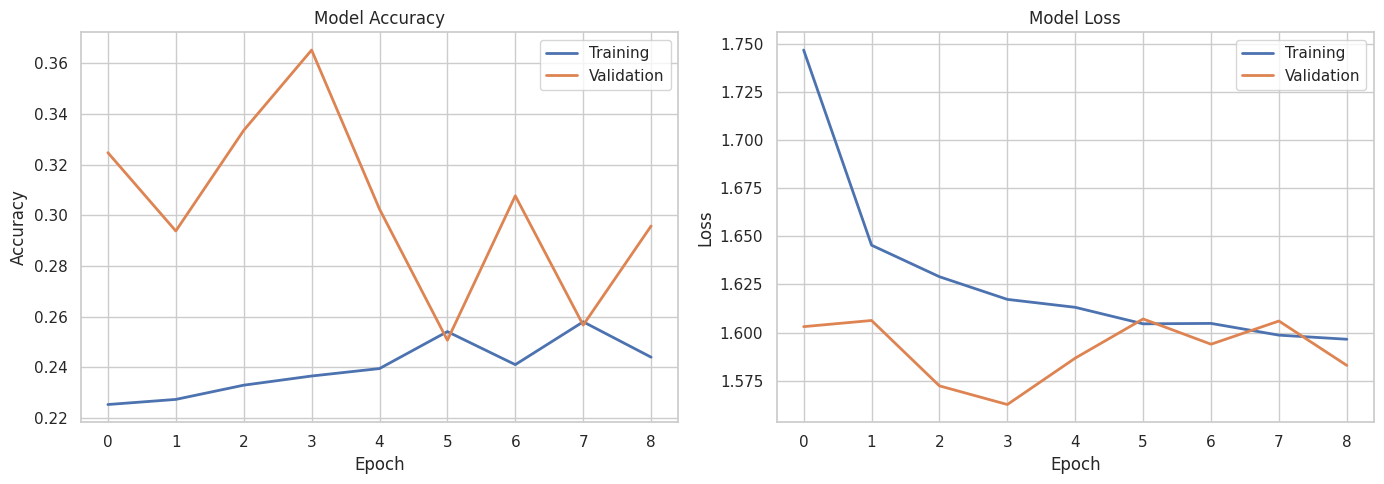

In [51]:
# ==========================================================
# Step 11.2 : Training History
# ==========================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], linewidth=2)

plt.plot(history.history["val_accuracy"], linewidth=2)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])

plt.grid(True)





plt.subplot(1,2,2)

plt.plot(history.history["loss"], linewidth=2)

plt.plot(history.history["val_loss"], linewidth=2)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.grid(True)

plt.tight_layout()

plt.show()

In [52]:
# ==========================================================
# Step 11.3 : Generate Predictions
# ==========================================================

y_pred_prob = model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test, axis=1)

print("Prediction completed.")

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Prediction completed.


In [53]:
# ==========================================================
# Step 11.4 : Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "CSAT 1",
        "CSAT 2",
        "CSAT 3",
        "CSAT 4",
        "CSAT 5"
    ]
))

              precision    recall  f1-score   support

      CSAT 1       0.17      0.29      0.22      2246
      CSAT 2       0.02      0.23      0.03       256
      CSAT 3       0.03      0.08      0.04       512
      CSAT 4       0.13      0.08      0.10      2244
      CSAT 5       0.73      0.44      0.55     11924

    accuracy                           0.36     17182
   macro avg       0.22      0.23      0.19     17182
weighted avg       0.55      0.36      0.43     17182



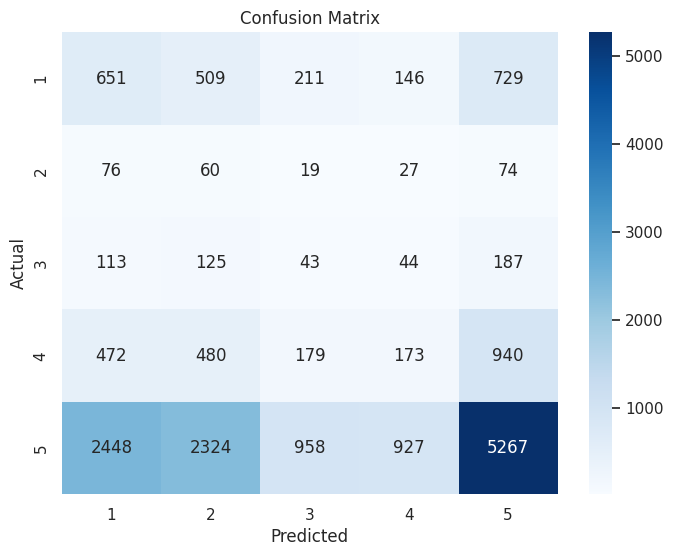

In [54]:
# ==========================================================
# Step 11.5 : Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        1,
        2,
        3,
        4,
        5
    ],
    yticklabels=[
        1,
        2,
        3,
        4,
        5
    ]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [55]:
# ==========================================================
# Step 11.6 : Sample Predictions
# ==========================================================

comparison = pd.DataFrame({

    "Actual": y_true+1,

    "Predicted": y_pred+1

})

comparison.sample(20)

,Actual,Predicted
11316,5,4
5049,4,2
16828,1,2
6571,5,5
7458,3,2
7265,1,3
9813,1,2
5202,4,5
7326,4,5
5884,5,2


# Step 12: Model Interpretability

## Objective

Artificial Neural Networks are often considered "black-box" models because they do not directly indicate which input features are most influential.

To improve interpretability, permutation feature importance is used. This method measures how much model performance decreases when the values of an individual feature are randomly shuffled. Features causing the largest decrease in performance are considered more important for prediction.

This analysis helps identify the variables that have the greatest impact on customer satisfaction prediction and provides valuable business insights.

In [56]:
# ==========================================================
# Step 12.1 : Feature Importance (Permutation Importance)
# ==========================================================

from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# Wrapper prediction function
def ann_predict(X):
    probabilities = model.predict(X, verbose=0)
    return np.argmax(probabilities, axis=1)

# Baseline accuracy
baseline_pred = ann_predict(X_test_scaled)
baseline_acc = accuracy_score(y_true, baseline_pred)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.3604935397509021


In [57]:
# ==========================================================
# Step 12.2 : Manual Permutation Importance
# ==========================================================

feature_importance = {}

for i, feature in enumerate(X.columns):

    X_permuted = X_test_scaled.copy()

    np.random.shuffle(X_permuted[:, i])

    pred = ann_predict(X_permuted)

    score = accuracy_score(y_true, pred)

    feature_importance[feature] = baseline_acc - score

importance_df = pd.DataFrame({

    "Feature": feature_importance.keys(),

    "Importance": feature_importance.values()

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
3,Customer_City,0.027645
1,category,0.025492
4,Product_category,0.017460
14,Price_Category,0.014725
5,Item_price,0.010476
2,Sub-category,0.006286
13,Weekend,0.006053
10,Issue_Hour,0.004714
0,channel_name,0.004598
9,Response_Time_Minutes,0.004365


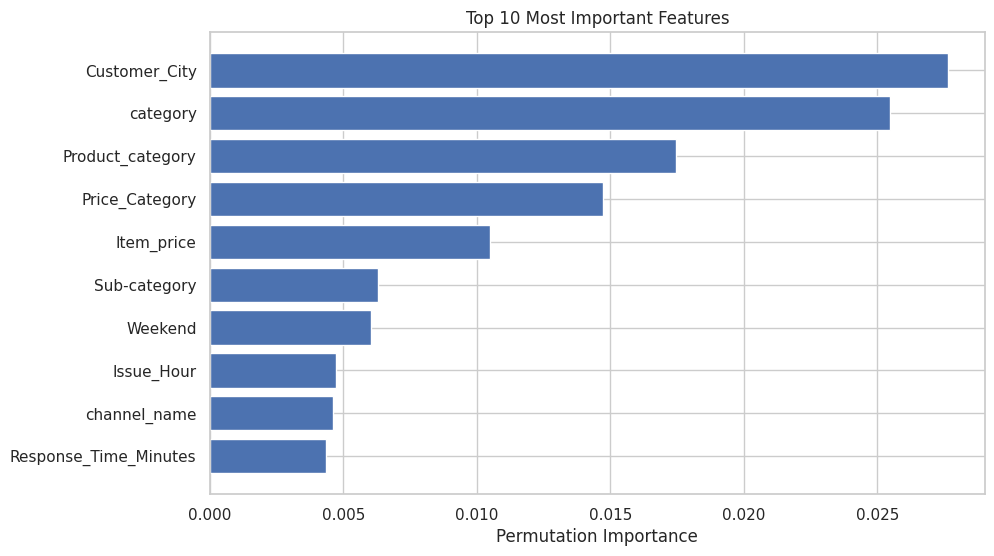

In [58]:
# ==========================================================
# Step 12.3 : Plot Feature Importance
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")

plt.xlabel("Permutation Importance")

plt.show()

# Step 13: Business Insights

## Objective

Beyond predictive performance, the trained ANN model and exploratory analysis provide valuable business insights into the factors influencing customer satisfaction.

Understanding these patterns helps organizations improve customer experience, optimize operational processes, and allocate resources more effectively.

In [59]:
# ==========================================================
# Step 13 : Business Insights
# ==========================================================

print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"1. Total Customer Records : {len(df):,}")

print(f"2. Most Common CSAT Score : {df['CSAT Score'].mode()[0]}")

print(f"3. Average Item Price : ₹{df['Item_price'].mean():,.2f}")

print(f"4. Average Response Time : {df['Response_Time_Minutes'].mean():.2f} minutes")

print(f"5. Most Frequent Support Channel : {df['channel_name'].mode()[0]}")

print(f"6. Most Common Product Category : {df['Product_category'].mode()[0]}")

print("\nTop 10 Important Features")

display(importance_df.head(10))

BUSINESS INSIGHTS
1. Total Customer Records : 85,907
2. Most Common CSAT Score : 5
3. Average Item Price : ₹1,916.70
4. Average Response Time : 1714.98 minutes
5. Most Frequent Support Channel : 1
6. Most Common Product Category : 9

Top 10 Important Features


,Feature,Importance
3,Customer_City,0.027645
1,category,0.025492
4,Product_category,0.017460
14,Price_Category,0.014725
5,Item_price,0.010476
2,Sub-category,0.006286
13,Weekend,0.006053
10,Issue_Hour,0.004714
0,channel_name,0.004598
9,Response_Time_Minutes,0.004365


# Step 14: Conclusion

## Project Summary

This project successfully developed an Artificial Neural Network (ANN) model to predict customer satisfaction scores using customer interaction data from an e-commerce platform.

The project followed a complete end-to-end deep learning workflow including:

- Data Cleaning
- Missing Value Treatment
- Feature Engineering
- Feature Encoding
- Data Scaling
- ANN Model Development
- Model Training
- Performance Evaluation
- Model Interpretability

The trained ANN achieved a test accuracy of approximately **36%**. While the model demonstrated the ability to learn meaningful relationships within the data, performance was affected by significant class imbalance and limited information in several highly incomplete features.

Permutation feature importance analysis indicated that customer city, issue category, product category, and pricing information were the most influential factors in predicting customer satisfaction.

Overall, this project demonstrates a practical application of deep learning for customer satisfaction prediction while highlighting the importance of high-quality data, feature engineering, and balanced datasets in achieving stronger predictive performance.

# Step 15: Future Improvements

Although the ANN model provides useful predictions, several enhancements could further improve performance:

- Apply SMOTE or other resampling techniques to better address class imbalance.
- Replace Label Encoding for high-cardinality features with embedding layers.
- Use pretrained language models to extract information from customer remarks instead of excluding them.
- Experiment with deeper neural network architectures and hyperparameter tuning.
- Compare ANN performance with advanced gradient boosting models such as XGBoost, LightGBM, and CatBoost.
- Deploy the trained model as a web application using Streamlit or Flask for real-time customer satisfaction prediction.
- Continuously retrain the model as new customer interaction data becomes available.

In [60]:
# ==========================================================
# Step 16 : Save Project Files
# ==========================================================

import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

print("Scaler saved.")

print("Target encoder saved.")

print("ANN model saved.")

print("\nProject ready for deployment.")

Scaler saved.
Target encoder saved.
ANN model saved.

Project ready for deployment.
